# Individual Metric: Parking Activity as a Measure of Neighborhood Vibrancy

## Introduction

For my individual part of the final project, I define the “best” neighborhood as the most vibrant and frequently visited area. In my view, a good neighborhood is a place where people want to go for restaurants, shopping, entertainment, work, and other activities.

To measure this idea, I use the Aggregated Parking Transactions dataset from the Pittsburgh Parking Authority. Parking transactions can act as a proxy for neighborhood activity. If a parking zone has many transactions, it suggests that many people are choosing to visit that area. Therefore, I treat higher parking activity as evidence that a neighborhood or local area is more popular and active.

In this analysis, I treat parking zones as representations of local areas within the city.


In [48]:
import pandas as pd
import matplotlib.pyplot as plt


## Loading the Dataset

The dataset contains parking transaction information aggregated by parking zone and time of day. Each row includes a parking zone, a time interval, meter transactions, mobile transactions, and payment information.

In [49]:
df = pd.read_csv("aggregated-transactions-2019-09-03.csv")
df.head()
df.columns
df.shape


(4481746, 9)

## Cleaning and Preparing the Data

The dataset separates transactions into meter transactions and mobile transactions. Since both represent people paying for parking, I combine them into one total transaction count. This total transaction count is the main variable used in my metric.


In [50]:
df["total_transactions"] = df["meter_transactions"] + df["mobile_transactions"]
df[["zone", "meter_transactions", "mobile_transactions", "total_transactions"]].head()
df["start"] = pd.to_datetime(df["start"])
df["hour"] = df["start"].dt.hour
df["date"] = df["start"].dt.date
df.head()

,_id,zone,start,end,utc_start,meter_transactions,meter_payments,mobile_transactions,mobile_payments,total_transactions,hour,date
0,5037,335 - Friendship Cedarville Lot,2014-01-04 11:40:00,2014-01-04T11:50:00,2014-01-04T16:40:00,2,1.00,0,0.0,2,11,2014-01-04
1,5038,341 - 18th & Sidney Lot,2014-01-04 11:40:00,2014-01-04T11:50:00,2014-01-04T16:40:00,2,1.50,0,0.0,2,11,2014-01-04
2,5039,342 - East Carson Lot,2014-01-04 11:40:00,2014-01-04T11:50:00,2014-01-04T16:40:00,1,7.00,0,0.0,1,11,2014-01-04
3,5040,343 - 19th & Carson Lot,2014-01-04 11:40:00,2014-01-04T11:50:00,2014-01-04T16:40:00,2,1.25,0,0.0,2,11,2014-01-04
4,5041,344 - 18th & Carson Lot,2014-01-04 11:40:00,2014-01-04T11:50:00,2014-01-04T16:40:00,7,12.00,0,0.0,7,11,2014-01-04


## Metric

My metric is based on total parking transactions.

A higher number of total parking transactions means that more people parked in that area. Under my definition of “best,” this suggests that the area is more vibrant, popular, and frequently visited.

The formula is: `total_transactions = meter_transactions + mobile_transactions`

In [51]:
zone_activity = df.groupby("zone")["total_transactions"].sum().reset_index()

zone_activity = zone_activity.sort_values(by="total_transactions", ascending=False)

zone_activity.head(10)

,zone,total_transactions
47,415 - SS & SSW,4628490
36,404 - Strip Disctrict,3103130
45,413 - Squirrel Hill,3050698
38,406 - Bloomfield (On-street),2395129
53,421 - NorthSide,2356951
43,411 - Shadyside,2331267
42,410 - Oakland 4,2321233
34,402 - Downtown 2,2170131
33,401 - Downtown 1,2132738
44,412 - East Liberty,2002645


## Top Parking Zones

The table below shows the top 10 parking zones by total parking transactions. These are the areas with the highest parking activity in the dataset.

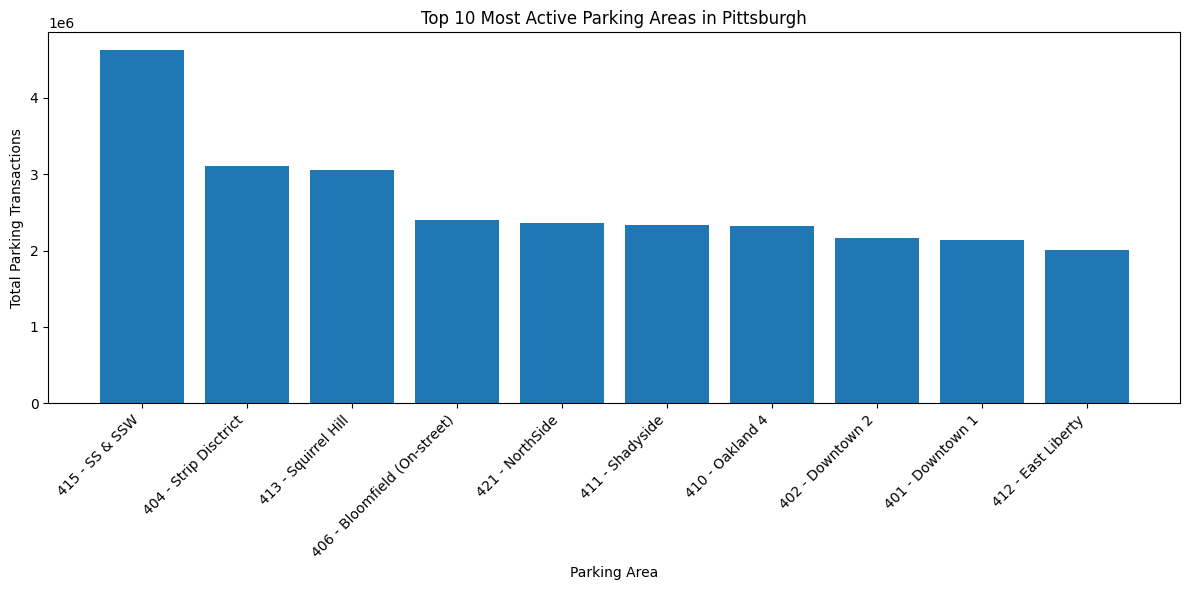

In [52]:
top10 = zone_activity.head(10)
top10

plt.figure(figsize=(12, 6))
plt.bar(top10["zone"], top10["total_transactions"])
plt.title("Top 10 Most Active Parking Areas in Pittsburgh")
plt.xlabel("Parking Area")
plt.ylabel("Total Parking Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


This visualization shows that a small number of parking areas account for a large portion of parking activity. This suggests that activity in Pittsburgh is concentrated in specific high-demand areas.

## Normalized Parking Activity Score

To make the results easier to compare, I create a normalized activity score. The busiest parking zone receives a score of 1.0, and all other zones are scored relative to it.


In [53]:
zone_activity["activity_score"] = zone_activity["total_transactions"] / zone_activity["total_transactions"].max()

zone_activity.head(10)


,zone,total_transactions,activity_score
47,415 - SS & SSW,4628490,1.000000
36,404 - Strip Disctrict,3103130,0.670441
45,413 - Squirrel Hill,3050698,0.659113
38,406 - Bloomfield (On-street),2395129,0.517475
53,421 - NorthSide,2356951,0.509227
43,411 - Shadyside,2331267,0.503678
42,410 - Oakland 4,2321233,0.501510
34,402 - Downtown 2,2170131,0.468864
33,401 - Downtown 1,2132738,0.460785
44,412 - East Liberty,2002645,0.432678


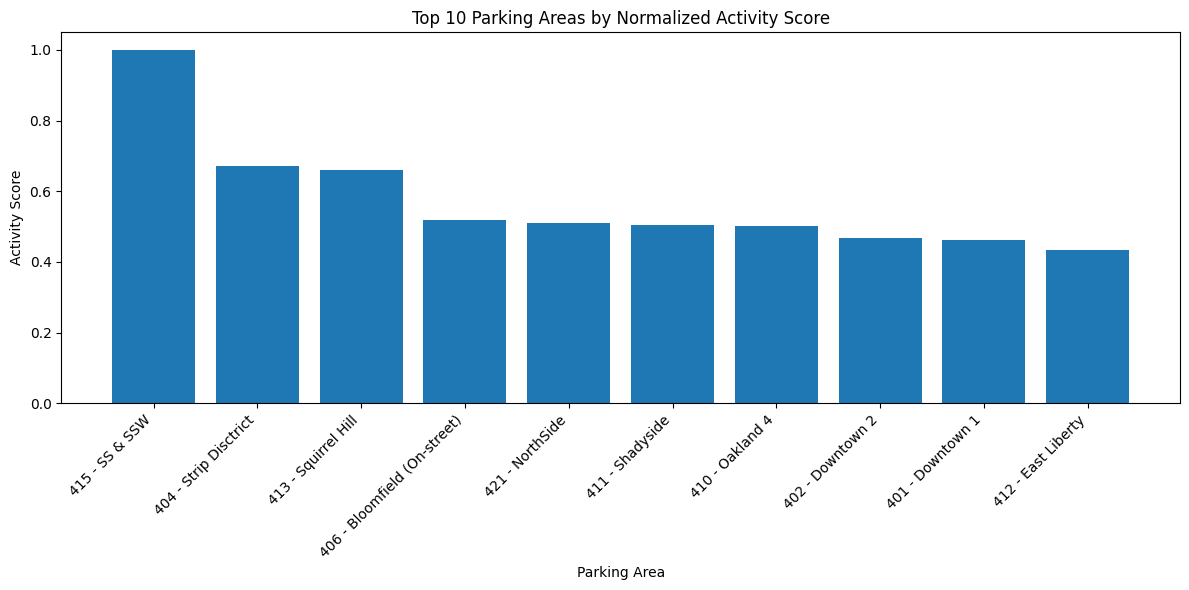

In [54]:
top10_score = zone_activity.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_score["zone"], top10_score["activity_score"])
plt.title("Top 10 Parking Areas by Normalized Activity Score")
plt.xlabel("Parking Area")
plt.ylabel("Activity Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


The normalized score makes the ranking easier to interpret. The top area receives a score of 1.0, while the other areas are compared against that top area.

## Parking Activity by Time of Day

I also looked at parking activity by hour. This does not determine the winner by itself, but it adds context by showing when parking activity is highest across the city.


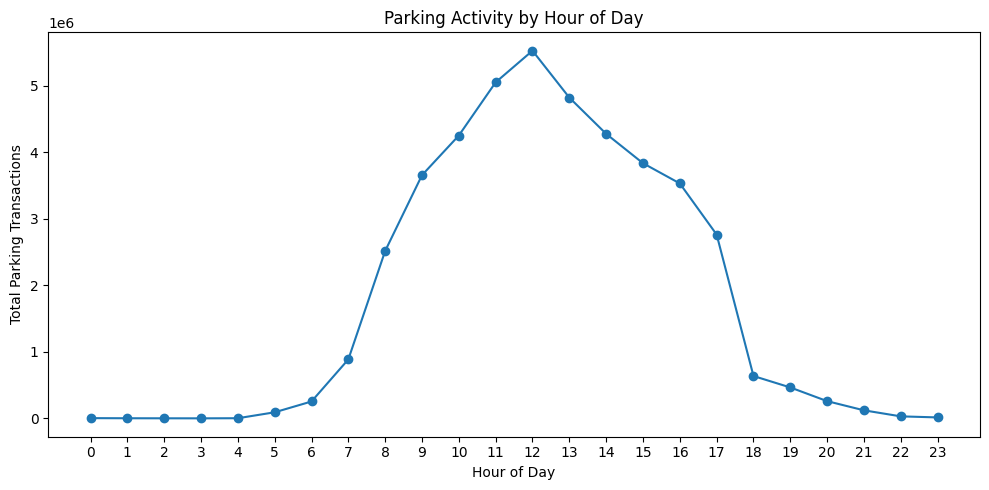

In [55]:
hourly_activity = df.groupby("hour")["total_transactions"].sum().reset_index()
hourly_activity

plt.figure(figsize=(10, 5))
plt.plot(hourly_activity["hour"], hourly_activity["total_transactions"], marker="o")
plt.title("Parking Activity by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Total Parking Transactions")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

This time-of-day graph shows when parking activity is highest. Higher activity during certain parts of the day may reflect shopping, dining, work, or entertainment patterns.

## Result

Based on the aggregated parking transaction data, the most active parking area is **415 - SS & SSW**, which has the highest number of total parking transactions in the dataset (4,628,490). 

In [56]:
best_zone = zone_activity.iloc[0]
best_zone

print("Best area based on parking activity:")
print(best_zone["zone"])
print("Total transactions:", best_zone["total_transactions"])
print("Activity score:", best_zone["activity_score"])

Best area based on parking activity:
415 - SS & SSW
Total transactions: 4628490
Activity score: 1.0


## Conclusion

In this analysis, I defined the “best” neighborhood as the most vibrant and frequently visited area, using parking transactions as a proxy for activity.

Based on the results, the area **415 - SS & SSW (South Side and SouthSide Works)** has the highest parking activity in the dataset. This parking zone broadly corresponds to Pittsburgh’s South Side area, which is officially divided into **South Side Flats** and **South Side Slopes**, with SouthSide Works serving as a major commercial and entertainment center within this region. This suggests that it is one of the most popular and frequently visited locations in Pittsburgh.

This finding aligns well with real-world characteristics of the area. South Side, especially along East Carson Street, is known for its dense concentration of restaurants and bars. In addition, SouthSide Works serves as a major shopping and entertainment center, attracting visitors throughout the day. These factors contribute to consistently high levels of parking demand.

Therefore, the data-driven result is supported by real-world evidence: areas with more amenities and attractions tend to draw more visitors, leading to higher parking activity. Under my definition of “best,” this makes the South Side area, particularly South Side Flats and nearby South Side Slopes, the strongest candidate for the best neighborhood under this metric.

However, my personal preference may be different from this data-driven result. Personally, I would probably prefer a neighborhood based more on safety and residential comfort. This means that even though **SS & SSW** is the best area under my parking-activity metric, another neighborhood could be my personal favorite if I focused on safety, quietness, or livability instead.